### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [197]:
# used pandas pd.read_csv function to import df dataset
data = pd.read_csv('/Users/brianplace/Git/assignment5_1_starter/data/coupons.csv')

In [198]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [199]:
# used pandas .info() to look at data info to identify nulls and/or missing data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [200]:
# data column 14 car has only 108 non-null inputs which is too many blanks therefore I am removing this data by using pandas drop function
data_minus_car_data = data.drop(columns=['car'])

In [201]:
# identify additional columns with null values using pandas .isnull function and then summing the counts with .sum()
data_minus_car_data.isnull().sum()

destination               0
passanger                 0
weather                   0
temperature               0
time                      0
coupon                    0
expiration                0
gender                    0
age                       0
maritalStatus             0
has_children              0
education                 0
occupation                0
income                    0
Bar                     107
CoffeeHouse             217
CarryAway               151
RestaurantLessThan20    130
Restaurant20To50        189
toCoupon_GEQ5min          0
toCoupon_GEQ15min         0
toCoupon_GEQ25min         0
direction_same            0
direction_opp             0
Y                         0
dtype: int64

In [202]:
# analyze rows with blanks in the establishment frequency columns i.e. bar, coffee house, etc... using pandas .isnull function
rows_with_null = data_minus_car_data[data_minus_car_data.isnull().any(axis=1)]
display(rows_with_null.isnull())

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12409,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
12410,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
12411,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
12412,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


3. Decide what to do about your missing data -- drop, replace, other...

In [203]:
# I want to see if I can pair down my data where there is rows where all five establishment cells are null using pandas .isnull() and .count() functions
columns_to_check = ['Bar', 'CoffeeHouse','CarryAway','RestaurantLessThan20','RestaurantLessThan20','Restaurant20To50']
records_with_all_null = data_minus_car_data[data_minus_car_data[columns_to_check].isnull().all(axis=1)]
display(records_with_all_null.isnull().count())

destination             42
passanger               42
weather                 42
temperature             42
time                    42
coupon                  42
expiration              42
gender                  42
age                     42
maritalStatus           42
has_children            42
education               42
occupation              42
income                  42
Bar                     42
CoffeeHouse             42
CarryAway               42
RestaurantLessThan20    42
Restaurant20To50        42
toCoupon_GEQ5min        42
toCoupon_GEQ15min       42
toCoupon_GEQ25min       42
direction_same          42
direction_opp           42
Y                       42
dtype: int64

In [207]:
data_scrubbed = data_minus_car_data

In [208]:
# I am dropping these records by using the pandas .dropna() function, as they will be outliers in the data set since they don't frequent an establishment where a coupon is being given

data_scrubbed.dropna(subset=['Bar', 'CoffeeHouse','CarryAway','RestaurantLessThan20','RestaurantLessThan20','Restaurant20To50'], how='all', inplace=True)


In [215]:
data_scrubbed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12642 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12642 non-null  object
 1   passanger             12642 non-null  object
 2   weather               12642 non-null  object
 3   temperature           12642 non-null  int64 
 4   time                  12642 non-null  object
 5   coupon                12642 non-null  object
 6   expiration            12642 non-null  object
 7   gender                12642 non-null  object
 8   age                   12642 non-null  object
 9   maritalStatus         12642 non-null  object
 10  has_children          12642 non-null  int64 
 11  education             12642 non-null  object
 12  occupation            12642 non-null  object
 13  income                12642 non-null  object
 14  Bar                   12642 non-null  object
 15  CoffeeHouse           12642 non-null  obj

In [217]:
# Replacing Never and Less1 to zero in all five establishement data columns by using the pandas .replace() function

replacements = {
    'Bar': {'never': '0', 'less1': '0'},
    'CoffeeHouse': {'never': '0', 'less1': '0'},
    'CarryAway': {'never': '0', 'less1': '0'},
    'RestaurantLessThan20': {'never': '0', 'less1': '0'},
    'Restaurant20To50': {'Never': '0', 'less1': '0'}
}

data_scrubbed.replace(replacements, inplace=True)



In [218]:
# replacing the remaining null cells in the five establishment columns with 0 by using pandas .fillna() function which fills in blanks for a defined criteria


data_scrubbed[['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']] = data_scrubbed[['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']].fillna(0)

4. What proportion of the total observations chose to accept the coupon?



In [222]:
# use pandas to count number of records with column Y equal to 1 which says person will use coupon and divide by total number of records
Y= 'Y'
will_use_coupon = (data_scrubbed[Y] == 1).sum()
total_rows = len(data_scrubbed[Y])
proportion_will_use = will_use_coupon / total_rows
print(f"The proportion is: {proportion_will_use}")

The proportion is: 0.5680272108843537


5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Coupons Offered')

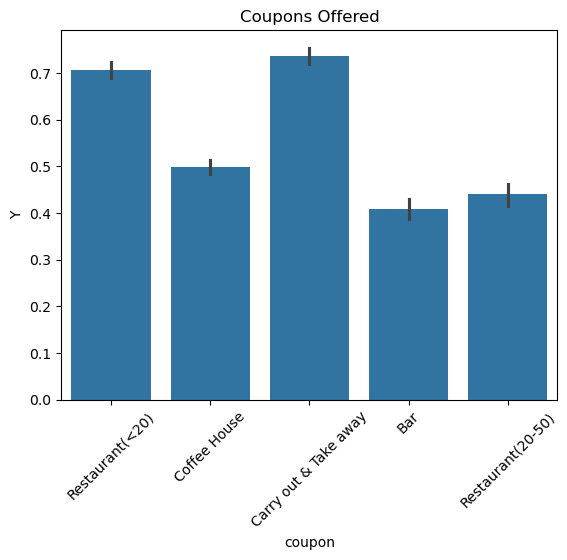

In [226]:
# Below is a seaborn barplot that is plotted against coupons accepted column which appears to be averaging the data in that column.  I dont find this very helpfull therefore I created a countplot below it.
sns.barplot(data=data_scrubbed,x='coupon',y='Y')
plt.xticks(rotation=45)
plt.title('Coupons Offered')

Text(0.5, 1.0, 'Coupons Offered')

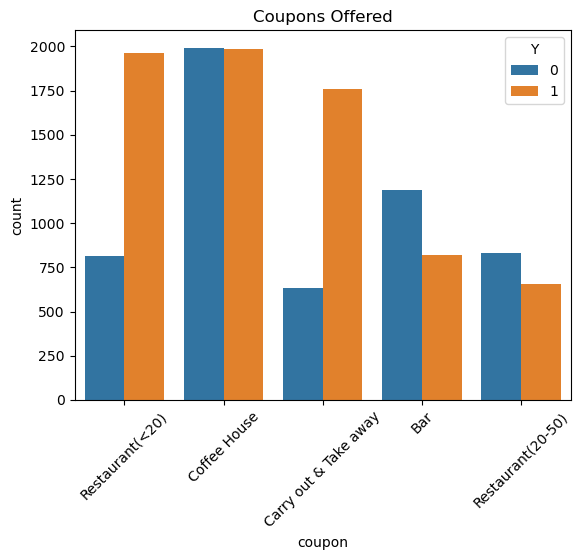

In [227]:
# A seaborn countplot displays probability of acceptance of coupon by coupon type

sns.countplot(data=data_scrubbed,x='coupon',hue='Y')
plt.xticks(rotation=45)
plt.title('Coupons Offered')

Text(0.5, 1.0, 'Coupons Offered')

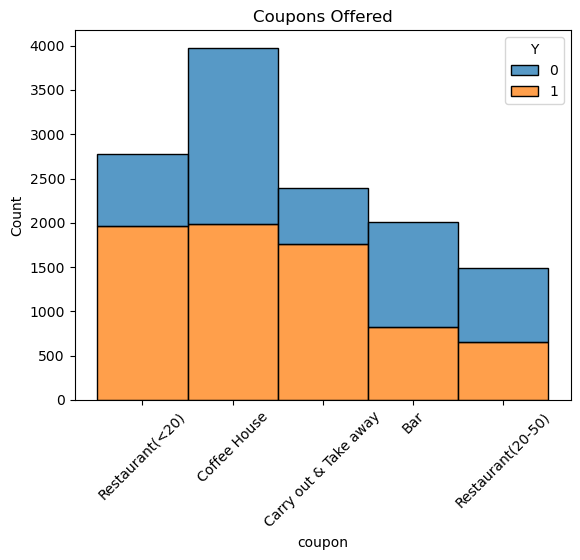

In [229]:
# I like the stacked verstion better by using a seaborn histplot
sns.histplot(data=data_scrubbed, x='coupon', hue='Y', multiple='stack')
plt.xticks(rotation=45)
plt.title('Coupons Offered')

6. Use a histogram to visualize the temperature column.

<Axes: xlabel='temperature', ylabel='Count'>

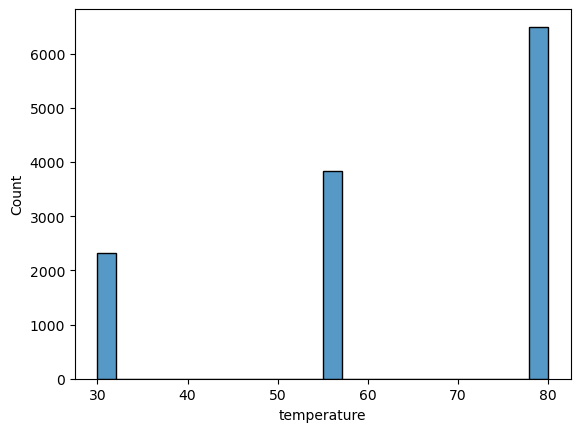

In [230]:
# used seaborn to visulize a histogram of temperature
sns.histplot(data=data_scrubbed,x='temperature')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [236]:
# used boolean filtering in pandas to creat a DF with only data whare the coupon column is populated with Bar
bar_coupons_only = data_scrubbed[data_scrubbed['coupon'] == 'Bar']


2. What proportion of bar coupons were accepted?


In [239]:
# use pandas to count number of records with column Y equal to 1 which says person will use coupon and divide by total number of records
Y= 'Y'
will_use_bar_coupon = (bar_coupons_only[Y] == 1).sum()
total_rows = len(bar_coupons_only[Y])
proportion_will_use_bar_coupon = will_use_bar_coupon / total_rows
print(f"The proportion is: {proportion_will_use_bar_coupon}")

The proportion is: 0.40936254980079684


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [252]:
# calculate the proportion of two subsets 1)number of acceptances for people who went 3 or less times to the bar a month and 2) number of acceptances for people who went more than 3 times to the bar a month
#1 create a subset using pandas isin() filtering methof of our bar only coupon dataframe where people went to the bar 3 or less times a month
#2 count the number of the 3 or less bar goers who used a bar coupon 
#3 count the total records of our bar only coupon dataframe
#4 divide the people who used coupon by the total records
#5 repeat for data subset of those who went to the bar more than 3 times a month
#6 compare proportions

#answer: Those who frequent the bar more or more likely to use the bar coupons

bar_three_or_less = bar_coupons_only[bar_coupons_only['Bar'].isin(['0', '1~3'])]
Bar3less_use_coupon = (bar_three_or_less[Y] == 1).sum()
total_barless3_coupon_rows = len(bar_three_or_less[Y])
proportion_bar3less_will_use_coupon = Bar3less_use_coupon / total_barless3_coupon_rows

bar_greater_than_three = bar_coupons_only[bar_coupons_only['Bar'].isin(['4~8', 'gt8'])]
Bar3more_use_coupon = (bar_greater_than_three[Y] == 1).sum()
total_barmore3_coupon_rows = len(bar_greater_than_three[Y])
proportion_bar3more_will_use_coupon = Bar3more_use_coupon / total_barmore3_coupon_rows

print(f"The proportion is: {proportion_bar3less_will_use_coupon}")
print(f"The proportion is: {proportion_bar3more_will_use_coupon}")

The proportion is: 0.37061769616026713
The proportion is: 0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [260]:
# calculate the proportion of a data subset where bar only coupon data is filtered for people that go to the bar more than once and are over 25 vs. the answer of number 25
#1 create a subset using pandas isin() filetring of our bar only coupon dataframe where people go to the bar more than once & where people are are over 25
#2 count the number of the above subset who used a bar coupon 
#3 count the total records of people that go to the bar more than once and over 25 dataframe
#4 divide the people who used by the total records
#5 compare proportions of step 4 above to answer from question number 2 

#answer: People over 25 and frequent the bar more than once are more probable to use the coupon than all people given bar coupons

bar_more1_over25 = bar_coupons_only[
    (bar_coupons_only['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (bar_coupons_only['age'] != '21')]
Barmore1over25_use_coupon = (bar_more1_over25[Y] == 1).sum()
total_barmore1over25_coupon_rows = len(bar_more1_over25[Y])
proportion_Barmore1over25_will_use_coupon = Barmore1over25_use_coupon / total_barmore1over25_coupon_rows

print(f"The proportion is: {proportion_Barmore1over25_will_use_coupon}")



The proportion is: 0.6883720930232559


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [262]:
# calculate the proportion of a data subset where bar only coupon data is filtered for people that go to the bar more than once and don't have kids in their car and don't work in Farming Fishing & Forestry
#1 create a subset using pandas isin() filetring of our bar only coupon dataframe where people go to the bar more than once & don't have kids in their car and don't work in Farming Fishing & Forestry
#2 count the number of the above subset who used a bar coupon 
#3 count the total records of people that go to the bar more than once and no kids and no fish
#4 divide the people who used by the total records
#5 compare proportions of step 4 above to answer from question number 2 

#answer: This group is the most likely by far to use the coupon

bar_more1_nokidorfish = bar_coupons_only[
    (bar_coupons_only['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (bar_coupons_only['passanger'] != 'Kid(s)')& 
    (bar_coupons_only['occupation'] != 'Farming Fishing & Forestry')]

Barmore1nokidorfish_use_coupon = (bar_more1_nokidorfish[Y] == 1).sum()
total_barmore1nokidorfish_coupon_rows = len(bar_more1_nokidorfish[Y])
proportion_Barmore1nokidorfish_will_use_coupon = Barmore1nokidorfish_use_coupon / total_barmore1nokidorfish_coupon_rows

print(f"The proportion is: {proportion_Barmore1nokidorfish_will_use_coupon}")


The proportion is: 0.7132486388384754


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [268]:
# same steps as 4 and 5 questions above

bar_more1_nokidwidow = bar_coupons_only[
    (bar_coupons_only['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (bar_coupons_only['passanger'] != 'Kid(s)')& 
    (bar_coupons_only['maritalStatus'] != 'Widowed')]

Barmore1nokidwidow_use_coupon = (bar_more1_nokidwidow[Y] == 1).sum()
total_barmore1nokidwidow_coupon_rows = len(bar_more1_nokidwidow[Y])
proportion_Barmore1nokidwidow_will_use_coupon = Barmore1nokidwidow_use_coupon / total_barmore1nokidwidow_coupon_rows

bar_more1_under30 = bar_coupons_only[
    (bar_coupons_only['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (bar_coupons_only['age'].isin(['21','26']))]

Barmore1under30_use_coupon = (bar_more1_under30[Y] == 1).sum()
total_barmore1under30_coupon_rows = len(bar_more1_under30[Y])
proportion_Barmore1under30_will_use_coupon = Barmore1under30_use_coupon / total_barmore1under30_coupon_rows


bar_cheap4_incless50 = bar_coupons_only[
    (bar_coupons_only['RestaurantLessThan20'].isin(['4~8', 'gt8'])) & 
    (bar_coupons_only['income'].isin(['$12500 - $24999','$25000 - $37499','$37500 - $49999']))]

barcheap4incless50_use_coupon = (bar_cheap4_incless50[Y] == 1).sum()
total_barcheap4incless50_coupon_rows = len(bar_cheap4_incless50[Y])
proportion_barcheap4incless50_will_use_coupon = barcheap4incless50_use_coupon / total_barcheap4incless50_coupon_rows



print(f"The proportion is: {proportion_Barmore1nokidwidow_will_use_coupon}")
print(f"The proportion is: {proportion_Barmore1under30_will_use_coupon}")
print(f"The proportion is: {proportion_barcheap4incless50_will_use_coupon}")

The proportion is: 0.7132486388384754
The proportion is: 0.7313432835820896
The proportion is: 0.4575645756457565


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
#Based on the data the more frequently you visit a bar and the younger you are the more likely you are to use a bar coupon.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [269]:
# used boolean filtering in pandas to creat a DF with only data whare the coupon column is populated with Coffee House aka CF
cf_coupons_only = data_scrubbed[data_scrubbed['coupon'] == 'Coffee House']


In [270]:
Y= 'Y'
will_use_cf_coupon = (cf_coupons_only[Y] == 1).sum()
totalcf_rows = len(cf_coupons_only[Y])
proportion_will_use_cf_coupon = will_use_cf_coupon / totalcf_rows
print(f"The proportion is: {proportion_will_use_cf_coupon}")

The proportion is: 0.49886792452830186


In [287]:
# Coffee House coupon users for drivers going in the same direction vs. the opposite direction
# calculate the proportion of a data subset where Coffee House only coupon data is filtered for people go at least once to a coffee house and that are going into the same direction
#1 create a subset using pandas isin() filetring of our Coffee House only coupon dataframe where people go to a coffee house at least once are driving in the same direction
#3 count the total records of people that go to the Coffee House at least once and drive in the same direction after getting the coupon
#4 divide the people who used by the total records
#5 Do the same steps 1-4 for drivers who are driving in the opposite direction 

#Hypothesis: People going in the same direction are slightly more probable to use the coffee coupon

ch_more1_indirection = cf_coupons_only[
    (cf_coupons_only['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])) & 
    (cf_coupons_only['direction_same']==1)]
chmore1indirection_use_coupon = (ch_more1_indirection[Y] == 1).sum()
total_chmore1indirection_coupon_rows = len(ch_more1_indirection[Y])
proportion_chmore1indirection_will_use_coupon = chmore1indirection_use_coupon / total_chmore1indirection_coupon_rows

ch_more1_opposite = cf_coupons_only[
    (cf_coupons_only['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])) & 
    (cf_coupons_only['direction_opp']==1)]
chmore1opposite_use_coupon = (ch_more1_opposite[Y] == 1).sum()
total_chmore1opposite_coupon_rows = len(ch_more1_opposite[Y])
proportion_chmore1opposite_will_use_coupon = chmore1opposite_use_coupon / total_chmore1opposite_coupon_rows



print(f"The proportion is: {proportion_chmore1indirection_will_use_coupon}")
print(f"The proportion is: {proportion_chmore1opposite_will_use_coupon}")



The proportion is: 0.735632183908046
The proportion is: 0.6435832274459975
